# Analysing Umpire 3 data

In [2]:
import pandas as pd
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [3]:
ump3_orig = pd.read_csv('Umpire_3.csv')

## Preprocessing

In [4]:

# Clean the data by categorizing the different pitch types 
def clean_df(orig_df):
    """
    Pitch types:
        ['SI' 'AB' 'SL' 'FC' 'CH' 'CU' 'FF' 'FS' 'EP' 'KC' 'FO' 'KN' 'SC' 'ST'
         'SV' 'CS' 'FA']
    Handedness: R=1, L=0
    Description: 'ball': 0, 'called_strike': 1
    Error in decision: 'correct': 0, 'incorrect': 1
    """
    df = orig_df.copy()
    # Drop nulls 
    df = df.dropna()
    
    # Map pitch types to binary columns
    unique_pt = df['pitch_type'].unique()
    fastballs = ['FF', 'FA', 'FT', 'SI', 'FC'] # 4 seam, 4 seam again, two seam, sinker, cutter
    changeups = ['CH', 'EP', 'FO', 'FS'] # Change, ephus, fork, split
    off_speed = ['SL', 'CU', 'ST', 'SV', 'CS'] # Slider, curve, sweeper, slurve, slow curve
    rare = ['KC', 'KN', 'SC'] # Knucle curve, knuckle ball, screwball
    # AB and AS are 'automatic ball/strike' so they are not included. This happens when something like a pitch clock violation occurs
    # Against the pitcher or the hitter

    # Create new binary columns
    df['fastball'] = df['pitch_type'].isin(fastballs).astype(int)
    df['changeup'] = df['pitch_type'].isin(changeups).astype(int)
    df['off_speed'] = df['pitch_type'].isin(off_speed).astype(int)
    df['rare'] = df['pitch_type'].isin(rare).astype(int)

    # Drop ptich_type column since it is not categorical
    df = df.drop(columns='pitch_type')
    
    # Same with error
    df['error_in_decision'] = df['error_in_decision'].map({'correct': 0, 'incorrect': 1})

    # Fix handedness
    df['stand'] = df['stand'].map({'R': 1, 'L': 0})
    df['p_throws'] = df['p_throws'].map({'R': 1, 'L': 0})
    
    df['description'] = df['description'].map({'ball': 0, 'called_strike': 1})


    # Max min scale the data to make coefficienst more interpretable
    scaler = MinMaxScaler()
    df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

    return df


ump3 = clean_df(ump3_orig)

In [5]:
X = ump3.sample(n=200, random_state=42) # Only take a small amount so that the modeling doesn't take 4-ever
y_true = np.array(X['error_in_decision'])

## I want to check the effects of:
1) Type of pitch (including velo and characteristics)
- pitch_type (binary for each type)

2) Count
- Balls, strikes, pitch_number, at_bat_number, description, most influential pitch type from 1

3) Important situaion
- delta_home_win_exp, delta_run_exp, home_score, away_score, on_3b/2/1

4) Pitch charactaristics
- plate_z, plate_x, release_speed, release_pos_x, release_pos_z, description, release_pos_y, pitch_location

5) Pitch Profile
- pfx_x, pfx_z, vx0, vy0, vz0, ax, ay, az

6) Dimentions of pitcher and hitter
- all_star_player, sz_bot, sz_top, stand, p_throws

In [12]:
loocv_ump3 = {}
model_accuracies = {}

## 1) Type of pitch

In [ ]:
Features = ['fastball', 'changeup', 'off_speed', 'rare']

Sampling: [changeup, fastball, intercept, observed, off_speed, rare]


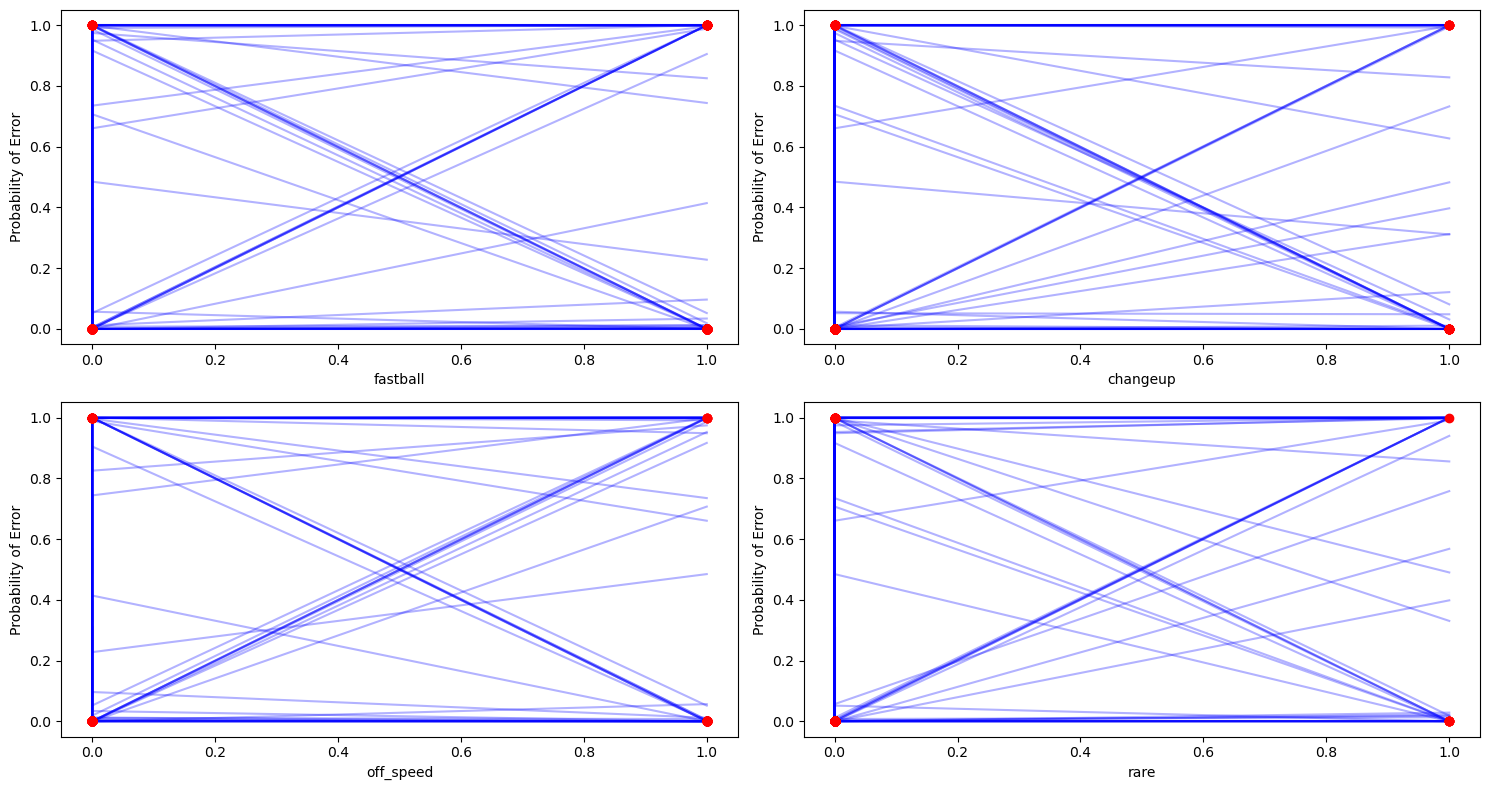

In [16]:
with pm.Model() as pitch_type_prior:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    observed = pm.Bernoulli('observed', p=p, observed=y_true)

    idata = pm.sample_prior_predictive(draws = 50, random_seed=42)

col = 0
row = 0
fig, axes = plt.subplots(ncols=2, nrows=(len(Features)//2) + (len(Features)%2), figsize=(15,8))
p_prior = idata.prior['p'].values

for feature in Features:
    X_sorted_idx = np.argsort(X[feature])
    X_sorted = X[feature].values[X_sorted_idx]
    true_sorted = y_true[X_sorted_idx] # ***Change this to the true value of the feature***

    for sig in p_prior[0]:
        sig_sort = sig[X_sorted_idx]
        axes[row, col].plot(X_sorted, sig_sort, color='blue', alpha=0.3)
    
    axes[row, col].scatter(X_sorted, true_sorted, color='red', label='True Value', zorder=3)

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Probability of Error')

    col += 1
    if col > 1:
        col = 0
        row += 1

plt.tight_layout()
plt.show()


Output()

Finished [100%]: Average Loss = 93.744


array([<Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'changeup'}>,
       <Axes: title={'center': 'off_speed'}>,
       <Axes: title={'center': 'rare'}>], dtype=object)

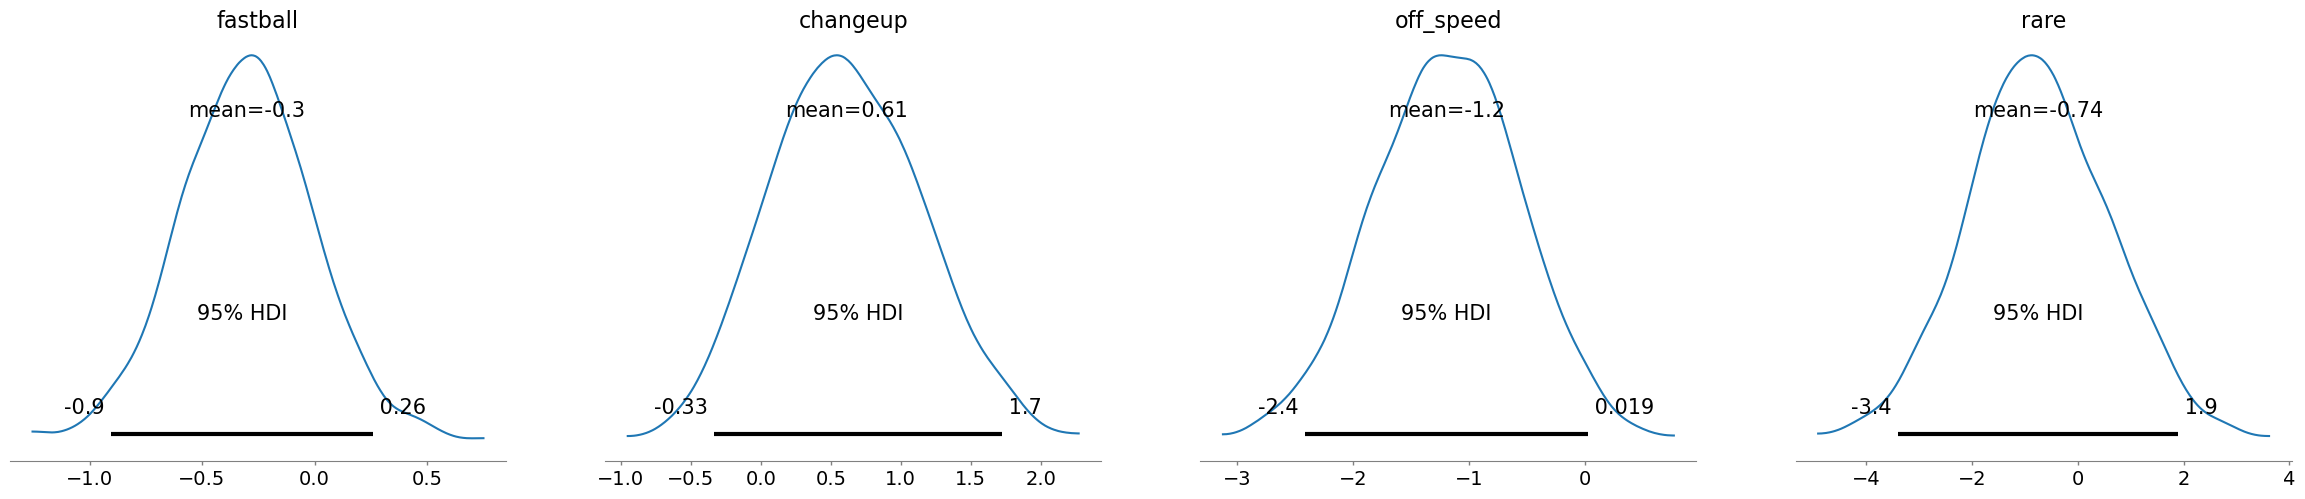

In [17]:
with pm.Model() as pitch_type_model:
    # priors 
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    # likelihood
    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    observed = pm.Bernoulli('observed', p=theta, observed=y_true)

    #ELPD_LOO
    mean_field = pm.fit(method = 'advi', obj_optimizer = pm.adagrad_window(learning_rate=1e-2))

trace_pitch = mean_field.sample(1000)

loocv_ump3["pitch_type"] = trace_pitch

az.plot_posterior(trace_pitch, var_names=['fastball', 'changeup', 'off_speed', 'rare'], hdi_prob=0.95)

### accuracy

In [19]:
feature_samples = {}

n_samples = len(trace_pitch.posterior['intercept'])
n_obs = len(X) 

all_preds = np.zeros((n_samples, n_obs))

for feature in ['intercept', 'fastball', 'changeup', 'off_speed', 'rare']:
    feature_samples[feature] = trace_pitch.posterior[feature].values.flatten()

for i in range(n_samples):
    mu = feature_samples['intercept'][i] + (
        (feature_samples['fastball'][i] * X[Features[0]]) +
        (feature_samples['changeup'][i] * X[Features[1]]) +
        (feature_samples['off_speed'][i] * X[Features[2]]) +
        (feature_samples['rare'][i] * X[Features[3]])
    )
    all_preds[i, :] = 1 / (1 + np.exp(-mu))

y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

accuracy = np.mean(y_pred == y_true)
model_accuracies["pitch_type"] = accuracy

print(f"Model accuracy: {model_accuracies['pitch_type']:.2f}")
print(f"Number of category 0: {np.sum(y_pred == 0)}")
print(f"Number of category 1: {np.sum(y_pred == 1)}")

Model accuracy: 0.82
Number of category 0: 180
Number of category 1: 20


## 2) Count

In [ ]:
Features = ['fastball', 'changeup', 'off_speed', 'rare']

Sampling: [changeup, fastball, intercept, observed, off_speed, rare]


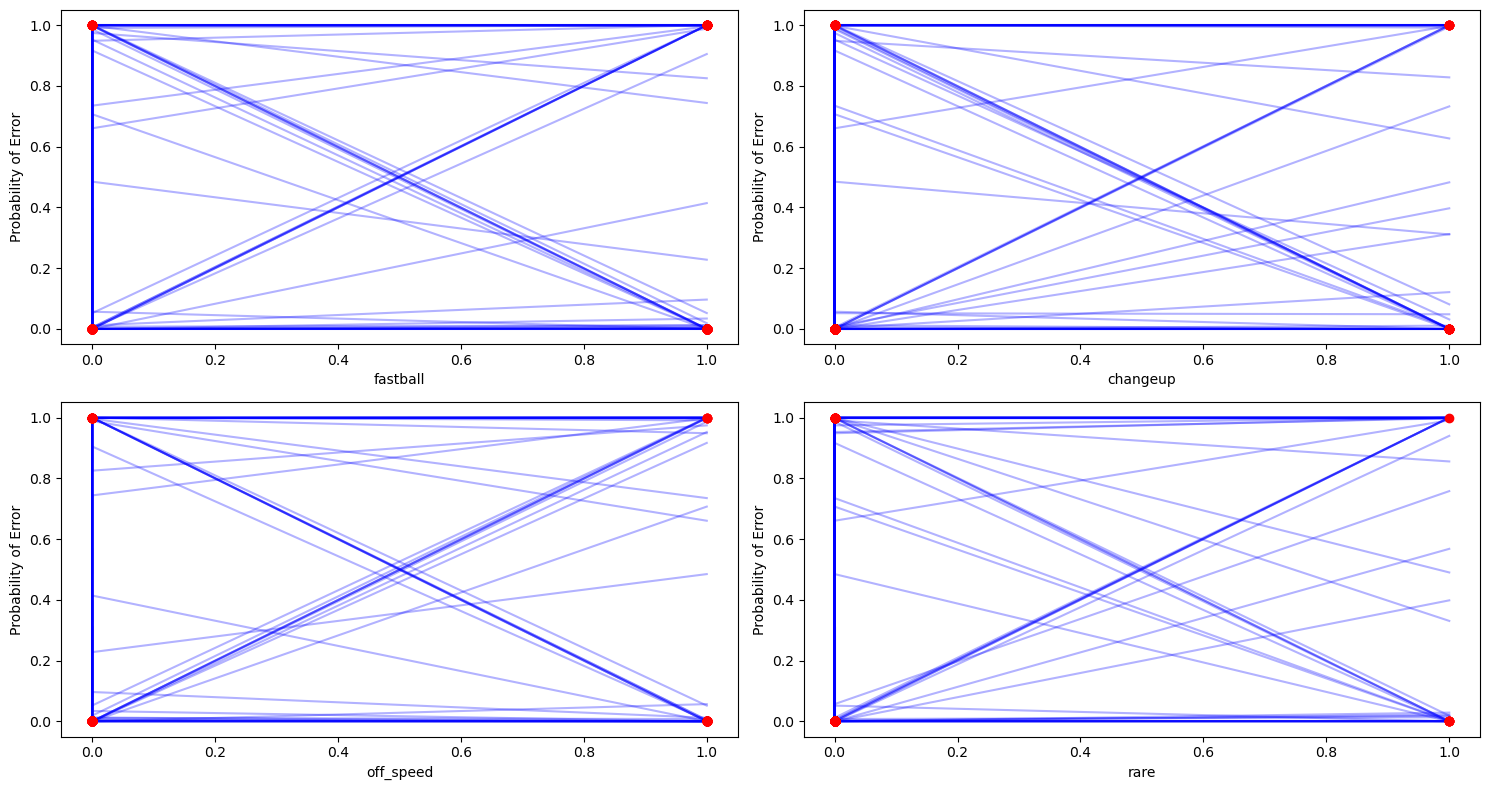

In [ ]:
with pm.Model() as pitch_type_prior:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    observed = pm.Bernoulli('observed', p=p, observed=y_true)

    idata = pm.sample_prior_predictive(draws = 50, random_seed=42)

col = 0
row = 0
fig, axes = plt.subplots(ncols=2, nrows=(len(Features)//2) + (len(Features)%2), figsize=(15,8))
p_prior = idata.prior['p'].values

for feature in Features:
    X_sorted_idx = np.argsort(X[feature])
    X_sorted = X[feature].values[X_sorted_idx]
    true_sorted = y_true[X_sorted_idx] # ***Change this to the true value of the feature***

    for sig in p_prior[0]:
        sig_sort = sig[X_sorted_idx]
        axes[row, col].plot(X_sorted, sig_sort, color='blue', alpha=0.3)
    
    axes[row, col].scatter(X_sorted, true_sorted, color='red', label='True Value', zorder=3)

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Probability of Error')

    col += 1
    if col > 1:
        col = 0
        row += 1

plt.tight_layout()
plt.show()


Output()

Finished [100%]: Average Loss = 93.744


array([<Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'changeup'}>,
       <Axes: title={'center': 'off_speed'}>,
       <Axes: title={'center': 'rare'}>], dtype=object)

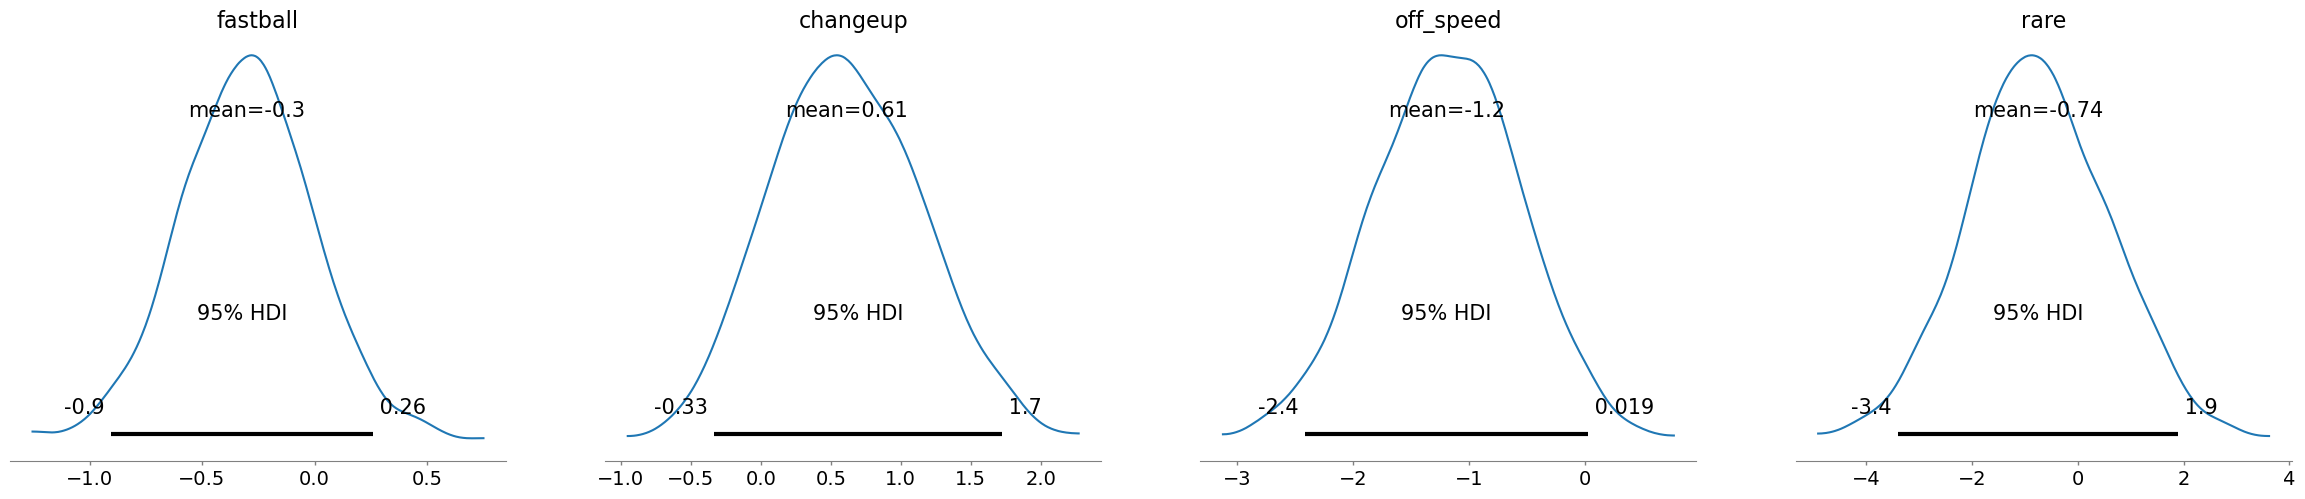

In [ ]:
with pm.Model() as pitch_type_model:
    # priors 
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    # likelihood
    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    observed = pm.Bernoulli('observed', p=theta, observed=y_true)

    #ELPD_LOO
    mean_field = pm.fit(method = 'advi', obj_optimizer = pm.adagrad_window(learning_rate=1e-2))

trace_pitch = mean_field.sample(1000)

loocv_ump3["pitch_type"] = trace_pitch

az.plot_posterior(trace_pitch, var_names=['fastball', 'changeup', 'off_speed', 'rare'], hdi_prob=0.95)

### accuracy

In [ ]:
feature_samples = {}

n_samples = len(trace_pitch.posterior['intercept'])
n_obs = len(X) 

all_preds = np.zeros((n_samples, n_obs))

for feature in ['intercept', 'fastball', 'changeup', 'off_speed', 'rare']:
    feature_samples[feature] = trace_pitch.posterior[feature].values.flatten()

for i in range(n_samples):
    mu = feature_samples['intercept'][i] + (
        (feature_samples['fastball'][i] * X[Features[0]]) +
        (feature_samples['changeup'][i] * X[Features[1]]) +
        (feature_samples['off_speed'][i] * X[Features[2]]) +
        (feature_samples['rare'][i] * X[Features[3]])
    )
    all_preds[i, :] = 1 / (1 + np.exp(-mu))

y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

accuracy = np.mean(y_pred == y_true)
model_accuracies["pitch_type"] = accuracy

print(f"Model accuracy: {model_accuracies['pitch_type']:.2f}")
print(f"Number of category 0: {np.sum(y_pred == 0)}")
print(f"Number of category 1: {np.sum(y_pred == 1)}")

Model accuracy: 0.82
Number of category 0: 180
Number of category 1: 20


## 3) Important Situation

In [ ]:
Features = ['fastball', 'changeup', 'off_speed', 'rare']

Sampling: [changeup, fastball, intercept, observed, off_speed, rare]


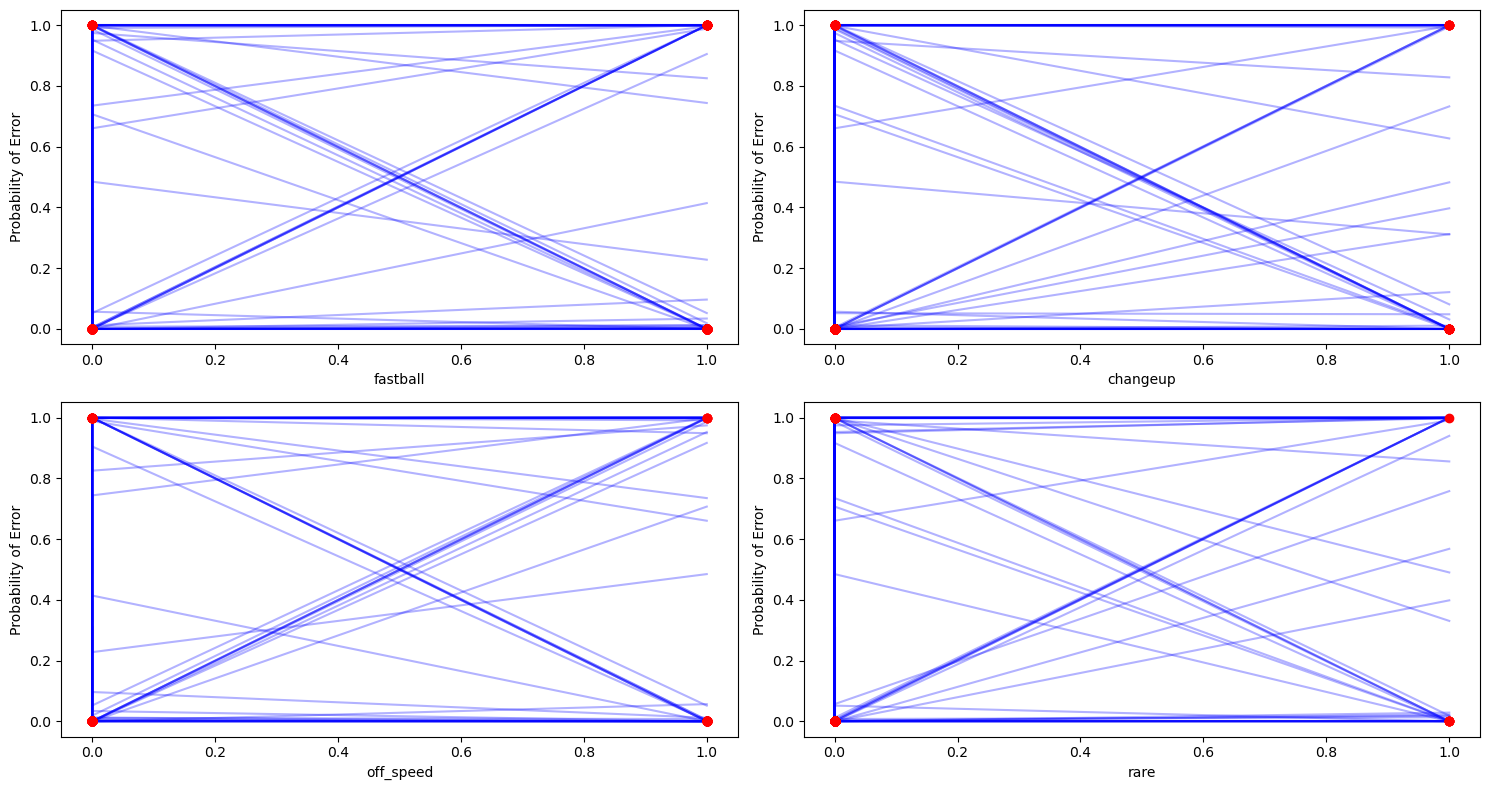

In [ ]:
with pm.Model() as pitch_type_prior:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    observed = pm.Bernoulli('observed', p=p, observed=y_true)

    idata = pm.sample_prior_predictive(draws = 50, random_seed=42)

col = 0
row = 0
fig, axes = plt.subplots(ncols=2, nrows=(len(Features)//2) + (len(Features)%2), figsize=(15,8))
p_prior = idata.prior['p'].values

for feature in Features:
    X_sorted_idx = np.argsort(X[feature])
    X_sorted = X[feature].values[X_sorted_idx]
    true_sorted = y_true[X_sorted_idx] # ***Change this to the true value of the feature***

    for sig in p_prior[0]:
        sig_sort = sig[X_sorted_idx]
        axes[row, col].plot(X_sorted, sig_sort, color='blue', alpha=0.3)
    
    axes[row, col].scatter(X_sorted, true_sorted, color='red', label='True Value', zorder=3)

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Probability of Error')

    col += 1
    if col > 1:
        col = 0
        row += 1

plt.tight_layout()
plt.show()


Output()

Finished [100%]: Average Loss = 93.744


array([<Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'changeup'}>,
       <Axes: title={'center': 'off_speed'}>,
       <Axes: title={'center': 'rare'}>], dtype=object)

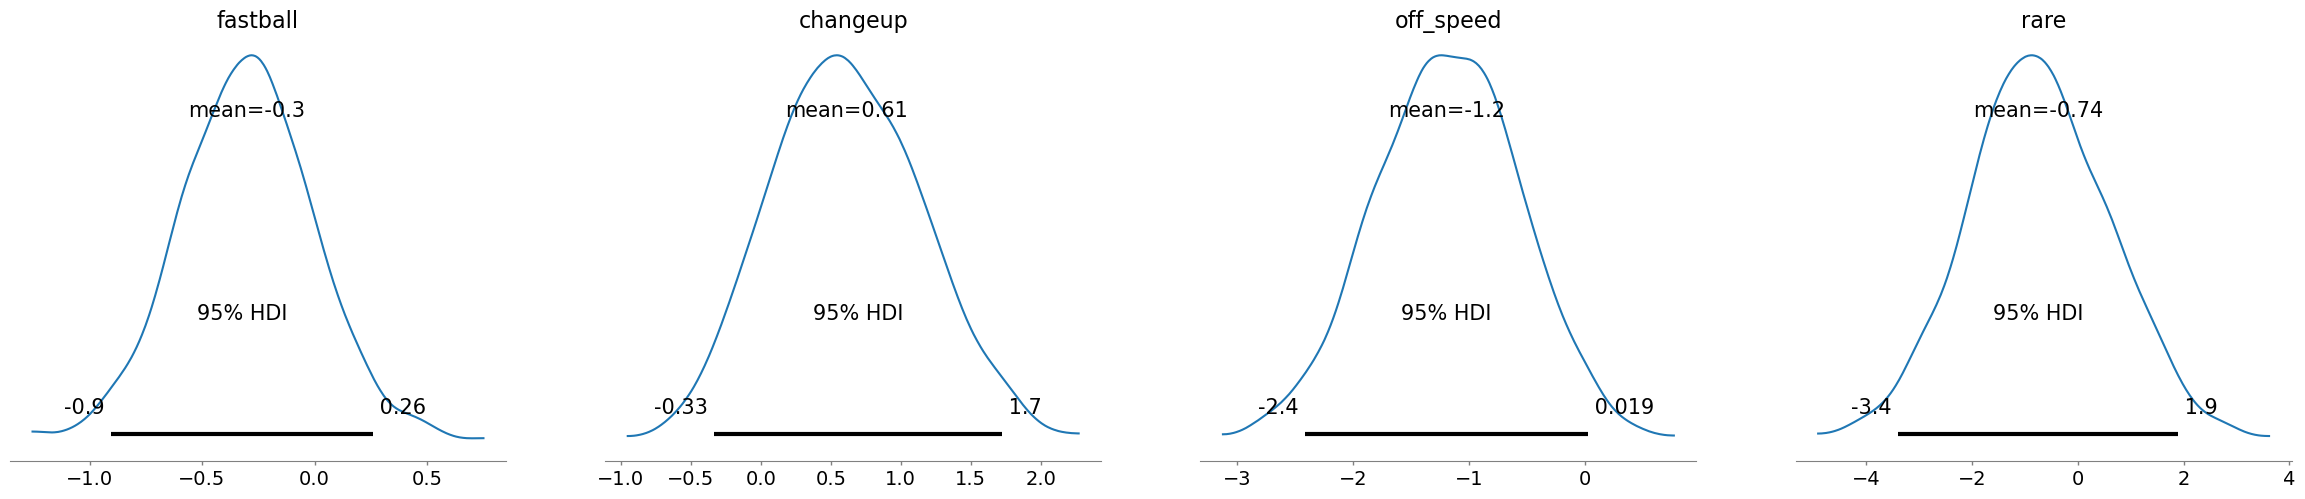

In [ ]:
with pm.Model() as pitch_type_model:
    # priors 
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    # likelihood
    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    observed = pm.Bernoulli('observed', p=theta, observed=y_true)

    #ELPD_LOO
    mean_field = pm.fit(method = 'advi', obj_optimizer = pm.adagrad_window(learning_rate=1e-2))

trace_pitch = mean_field.sample(1000)

loocv_ump3["pitch_type"] = trace_pitch

az.plot_posterior(trace_pitch, var_names=['fastball', 'changeup', 'off_speed', 'rare'], hdi_prob=0.95)

### accuracy

In [ ]:
feature_samples = {}

n_samples = len(trace_pitch.posterior['intercept'])
n_obs = len(X) 

all_preds = np.zeros((n_samples, n_obs))

for feature in ['intercept', 'fastball', 'changeup', 'off_speed', 'rare']:
    feature_samples[feature] = trace_pitch.posterior[feature].values.flatten()

for i in range(n_samples):
    mu = feature_samples['intercept'][i] + (
        (feature_samples['fastball'][i] * X[Features[0]]) +
        (feature_samples['changeup'][i] * X[Features[1]]) +
        (feature_samples['off_speed'][i] * X[Features[2]]) +
        (feature_samples['rare'][i] * X[Features[3]])
    )
    all_preds[i, :] = 1 / (1 + np.exp(-mu))

y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

accuracy = np.mean(y_pred == y_true)
model_accuracies["pitch_type"] = accuracy

print(f"Model accuracy: {model_accuracies['pitch_type']:.2f}")
print(f"Number of category 0: {np.sum(y_pred == 0)}")
print(f"Number of category 1: {np.sum(y_pred == 1)}")

Model accuracy: 0.82
Number of category 0: 180
Number of category 1: 20


## 4) Pitch Characteristics

In [ ]:
Features = ['fastball', 'changeup', 'off_speed', 'rare']

Sampling: [changeup, fastball, intercept, observed, off_speed, rare]


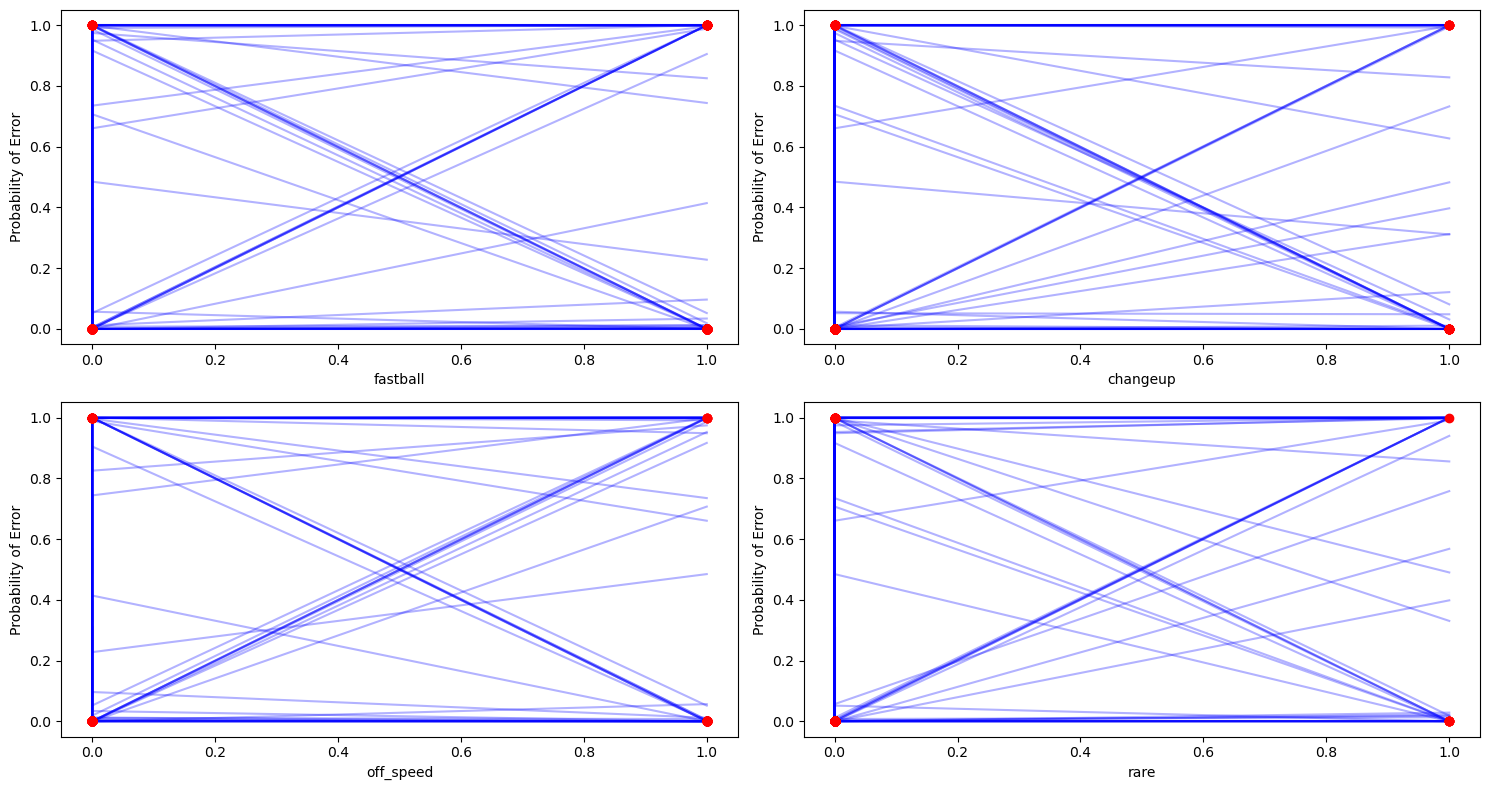

In [ ]:
with pm.Model() as pitch_type_prior:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    observed = pm.Bernoulli('observed', p=p, observed=y_true)

    idata = pm.sample_prior_predictive(draws = 50, random_seed=42)

col = 0
row = 0
fig, axes = plt.subplots(ncols=2, nrows=(len(Features)//2) + (len(Features)%2), figsize=(15,8))
p_prior = idata.prior['p'].values

for feature in Features:
    X_sorted_idx = np.argsort(X[feature])
    X_sorted = X[feature].values[X_sorted_idx]
    true_sorted = y_true[X_sorted_idx] # ***Change this to the true value of the feature***

    for sig in p_prior[0]:
        sig_sort = sig[X_sorted_idx]
        axes[row, col].plot(X_sorted, sig_sort, color='blue', alpha=0.3)
    
    axes[row, col].scatter(X_sorted, true_sorted, color='red', label='True Value', zorder=3)

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Probability of Error')

    col += 1
    if col > 1:
        col = 0
        row += 1

plt.tight_layout()
plt.show()


Output()

Finished [100%]: Average Loss = 93.744


array([<Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'changeup'}>,
       <Axes: title={'center': 'off_speed'}>,
       <Axes: title={'center': 'rare'}>], dtype=object)

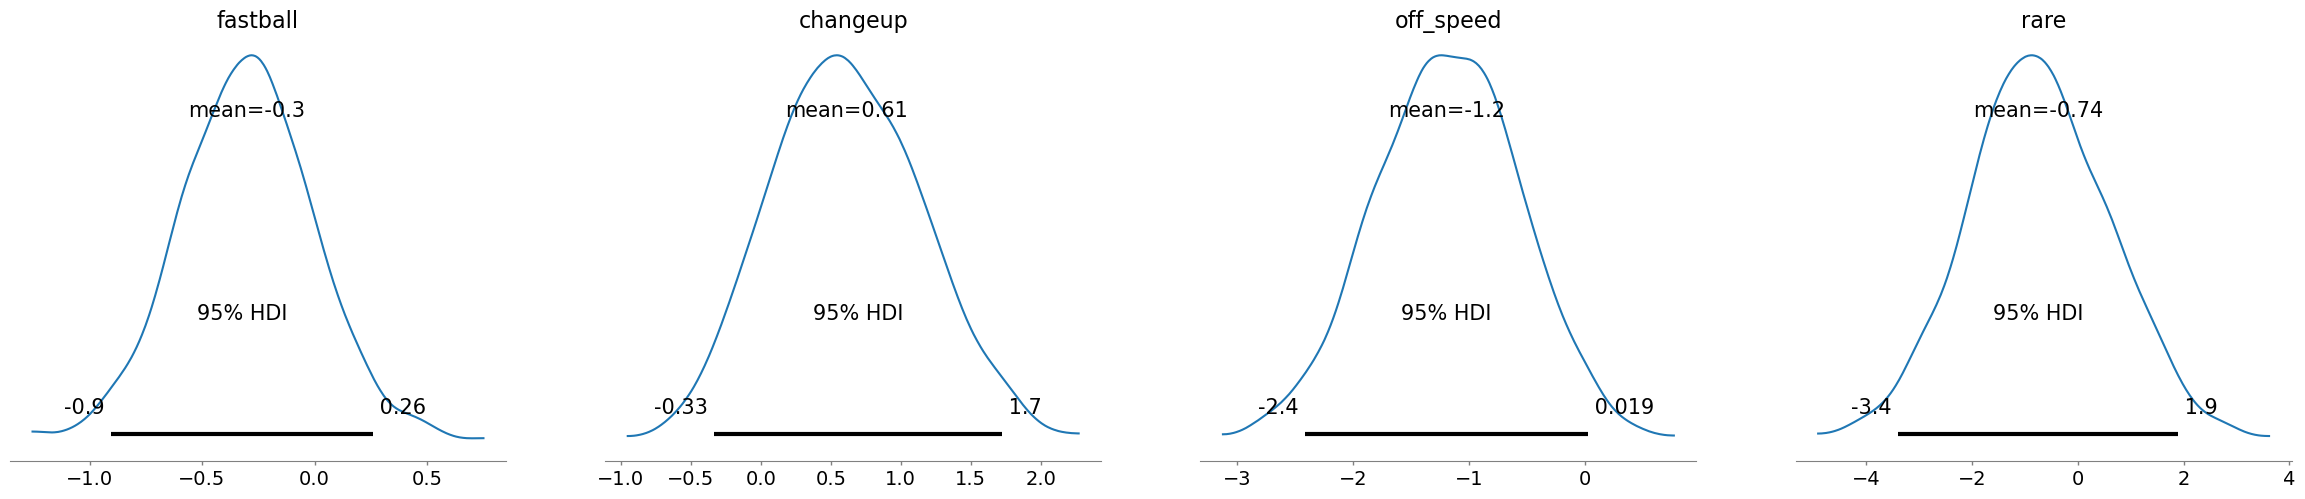

In [ ]:
with pm.Model() as pitch_type_model:
    # priors 
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    # likelihood
    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    observed = pm.Bernoulli('observed', p=theta, observed=y_true)

    #ELPD_LOO
    mean_field = pm.fit(method = 'advi', obj_optimizer = pm.adagrad_window(learning_rate=1e-2))

trace_pitch = mean_field.sample(1000)

loocv_ump3["pitch_type"] = trace_pitch

az.plot_posterior(trace_pitch, var_names=['fastball', 'changeup', 'off_speed', 'rare'], hdi_prob=0.95)

### accuracy

In [ ]:
feature_samples = {}

n_samples = len(trace_pitch.posterior['intercept'])
n_obs = len(X) 

all_preds = np.zeros((n_samples, n_obs))

for feature in ['intercept', 'fastball', 'changeup', 'off_speed', 'rare']:
    feature_samples[feature] = trace_pitch.posterior[feature].values.flatten()

for i in range(n_samples):
    mu = feature_samples['intercept'][i] + (
        (feature_samples['fastball'][i] * X[Features[0]]) +
        (feature_samples['changeup'][i] * X[Features[1]]) +
        (feature_samples['off_speed'][i] * X[Features[2]]) +
        (feature_samples['rare'][i] * X[Features[3]])
    )
    all_preds[i, :] = 1 / (1 + np.exp(-mu))

y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

accuracy = np.mean(y_pred == y_true)
model_accuracies["pitch_type"] = accuracy

print(f"Model accuracy: {model_accuracies['pitch_type']:.2f}")
print(f"Number of category 0: {np.sum(y_pred == 0)}")
print(f"Number of category 1: {np.sum(y_pred == 1)}")

Model accuracy: 0.82
Number of category 0: 180
Number of category 1: 20


## 5) Pitch Profile

In [ ]:
Features = ['fastball', 'changeup', 'off_speed', 'rare']

Sampling: [changeup, fastball, intercept, observed, off_speed, rare]


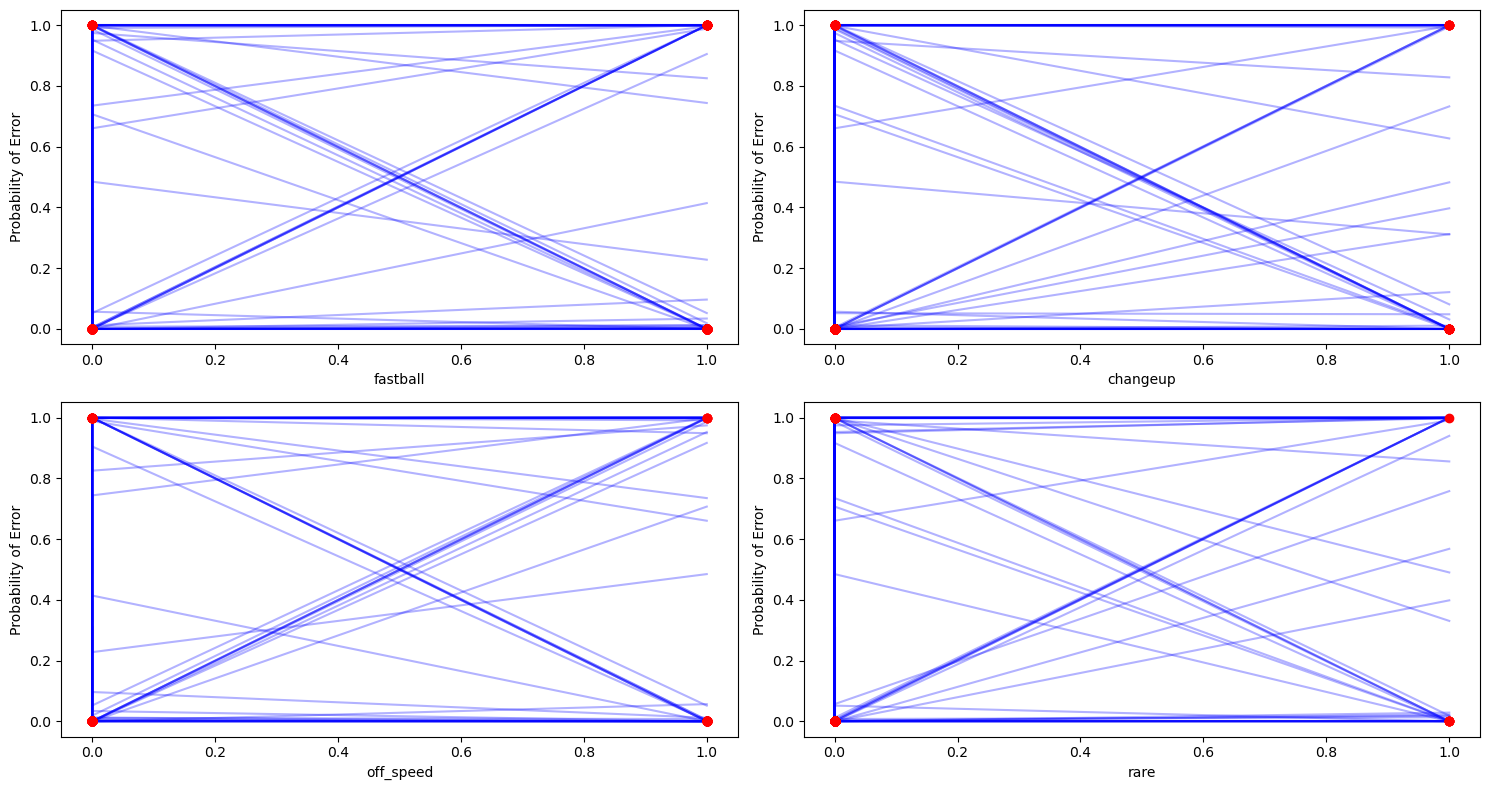

In [ ]:
with pm.Model() as pitch_type_prior:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    observed = pm.Bernoulli('observed', p=p, observed=y_true)

    idata = pm.sample_prior_predictive(draws = 50, random_seed=42)

col = 0
row = 0
fig, axes = plt.subplots(ncols=2, nrows=(len(Features)//2) + (len(Features)%2), figsize=(15,8))
p_prior = idata.prior['p'].values

for feature in Features:
    X_sorted_idx = np.argsort(X[feature])
    X_sorted = X[feature].values[X_sorted_idx]
    true_sorted = y_true[X_sorted_idx] # ***Change this to the true value of the feature***

    for sig in p_prior[0]:
        sig_sort = sig[X_sorted_idx]
        axes[row, col].plot(X_sorted, sig_sort, color='blue', alpha=0.3)
    
    axes[row, col].scatter(X_sorted, true_sorted, color='red', label='True Value', zorder=3)

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Probability of Error')

    col += 1
    if col > 1:
        col = 0
        row += 1

plt.tight_layout()
plt.show()


Output()

Finished [100%]: Average Loss = 93.744


array([<Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'changeup'}>,
       <Axes: title={'center': 'off_speed'}>,
       <Axes: title={'center': 'rare'}>], dtype=object)

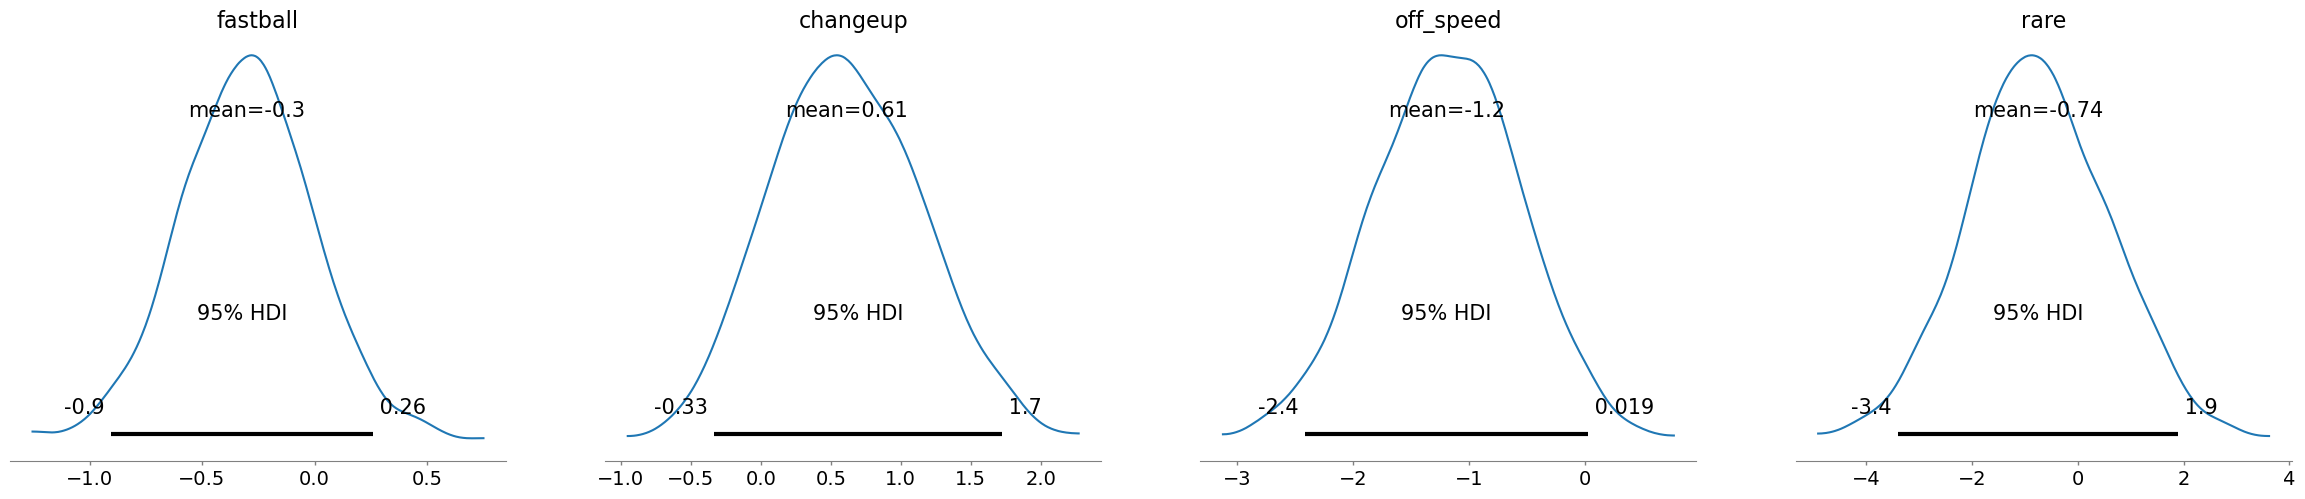

In [ ]:
with pm.Model() as pitch_type_model:
    # priors 
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    # likelihood
    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    observed = pm.Bernoulli('observed', p=theta, observed=y_true)

    #ELPD_LOO
    mean_field = pm.fit(method = 'advi', obj_optimizer = pm.adagrad_window(learning_rate=1e-2))

trace_pitch = mean_field.sample(1000)

loocv_ump3["pitch_type"] = trace_pitch

az.plot_posterior(trace_pitch, var_names=['fastball', 'changeup', 'off_speed', 'rare'], hdi_prob=0.95)

### accuracy

In [ ]:
feature_samples = {}

n_samples = len(trace_pitch.posterior['intercept'])
n_obs = len(X) 

all_preds = np.zeros((n_samples, n_obs))

for feature in ['intercept', 'fastball', 'changeup', 'off_speed', 'rare']:
    feature_samples[feature] = trace_pitch.posterior[feature].values.flatten()

for i in range(n_samples):
    mu = feature_samples['intercept'][i] + (
        (feature_samples['fastball'][i] * X[Features[0]]) +
        (feature_samples['changeup'][i] * X[Features[1]]) +
        (feature_samples['off_speed'][i] * X[Features[2]]) +
        (feature_samples['rare'][i] * X[Features[3]])
    )
    all_preds[i, :] = 1 / (1 + np.exp(-mu))

y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

accuracy = np.mean(y_pred == y_true)
model_accuracies["pitch_type"] = accuracy

print(f"Model accuracy: {model_accuracies['pitch_type']:.2f}")
print(f"Number of category 0: {np.sum(y_pred == 0)}")
print(f"Number of category 1: {np.sum(y_pred == 1)}")

Model accuracy: 0.82
Number of category 0: 180
Number of category 1: 20


## 6) Pitcher / Hitter Dims

In [ ]:
Features = ['fastball', 'changeup', 'off_speed', 'rare']

Sampling: [changeup, fastball, intercept, observed, off_speed, rare]


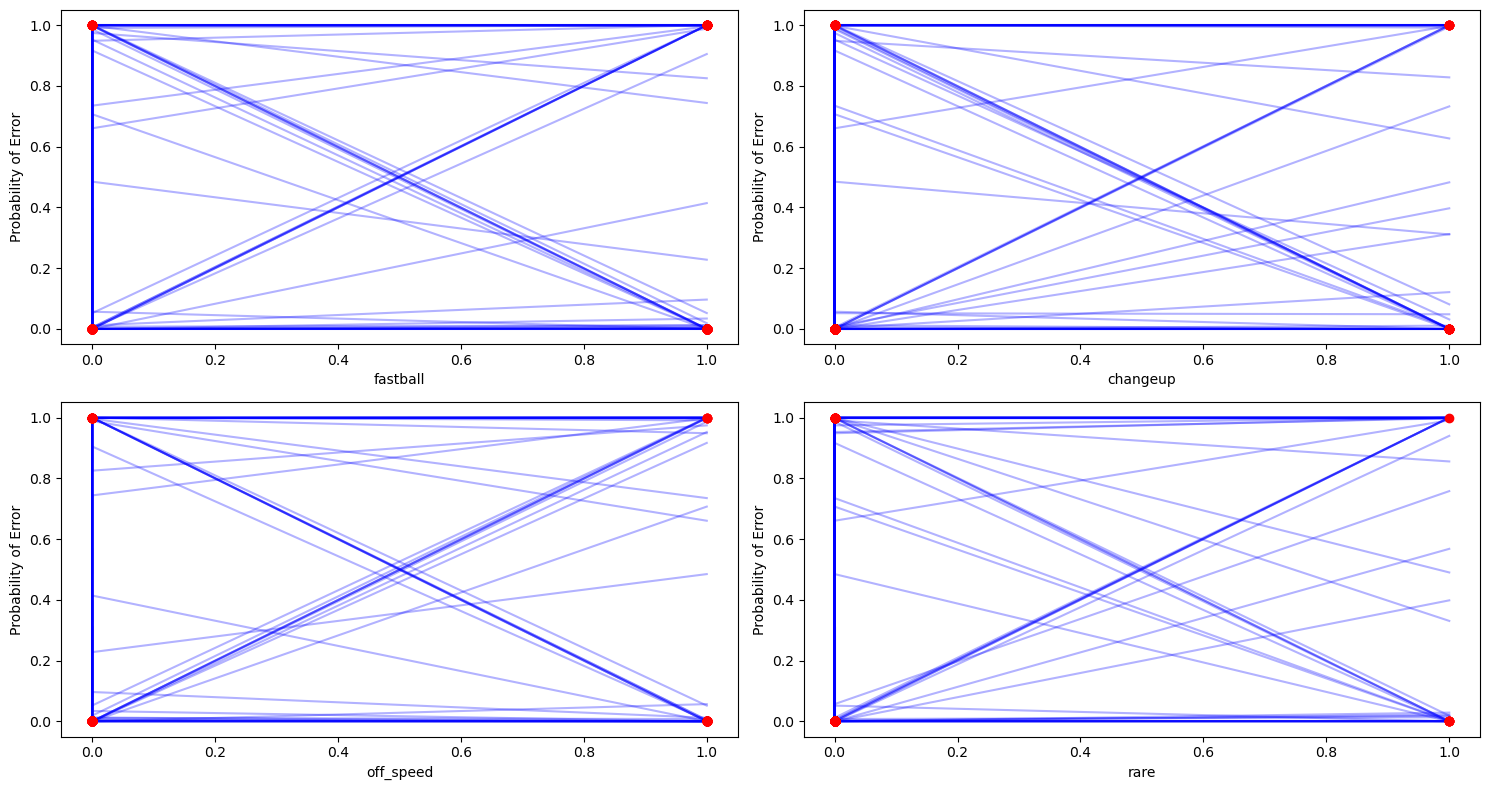

In [ ]:
with pm.Model() as pitch_type_prior:
    # Priors
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    p = pm.Deterministic('p', pm.math.sigmoid(mu))

    observed = pm.Bernoulli('observed', p=p, observed=y_true)

    idata = pm.sample_prior_predictive(draws = 50, random_seed=42)

col = 0
row = 0
fig, axes = plt.subplots(ncols=2, nrows=(len(Features)//2) + (len(Features)%2), figsize=(15,8))
p_prior = idata.prior['p'].values

for feature in Features:
    X_sorted_idx = np.argsort(X[feature])
    X_sorted = X[feature].values[X_sorted_idx]
    true_sorted = y_true[X_sorted_idx] # ***Change this to the true value of the feature***

    for sig in p_prior[0]:
        sig_sort = sig[X_sorted_idx]
        axes[row, col].plot(X_sorted, sig_sort, color='blue', alpha=0.3)
    
    axes[row, col].scatter(X_sorted, true_sorted, color='red', label='True Value', zorder=3)

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Probability of Error')

    col += 1
    if col > 1:
        col = 0
        row += 1

plt.tight_layout()
plt.show()


Output()

Finished [100%]: Average Loss = 93.744


array([<Axes: title={'center': 'fastball'}>,
       <Axes: title={'center': 'changeup'}>,
       <Axes: title={'center': 'off_speed'}>,
       <Axes: title={'center': 'rare'}>], dtype=object)

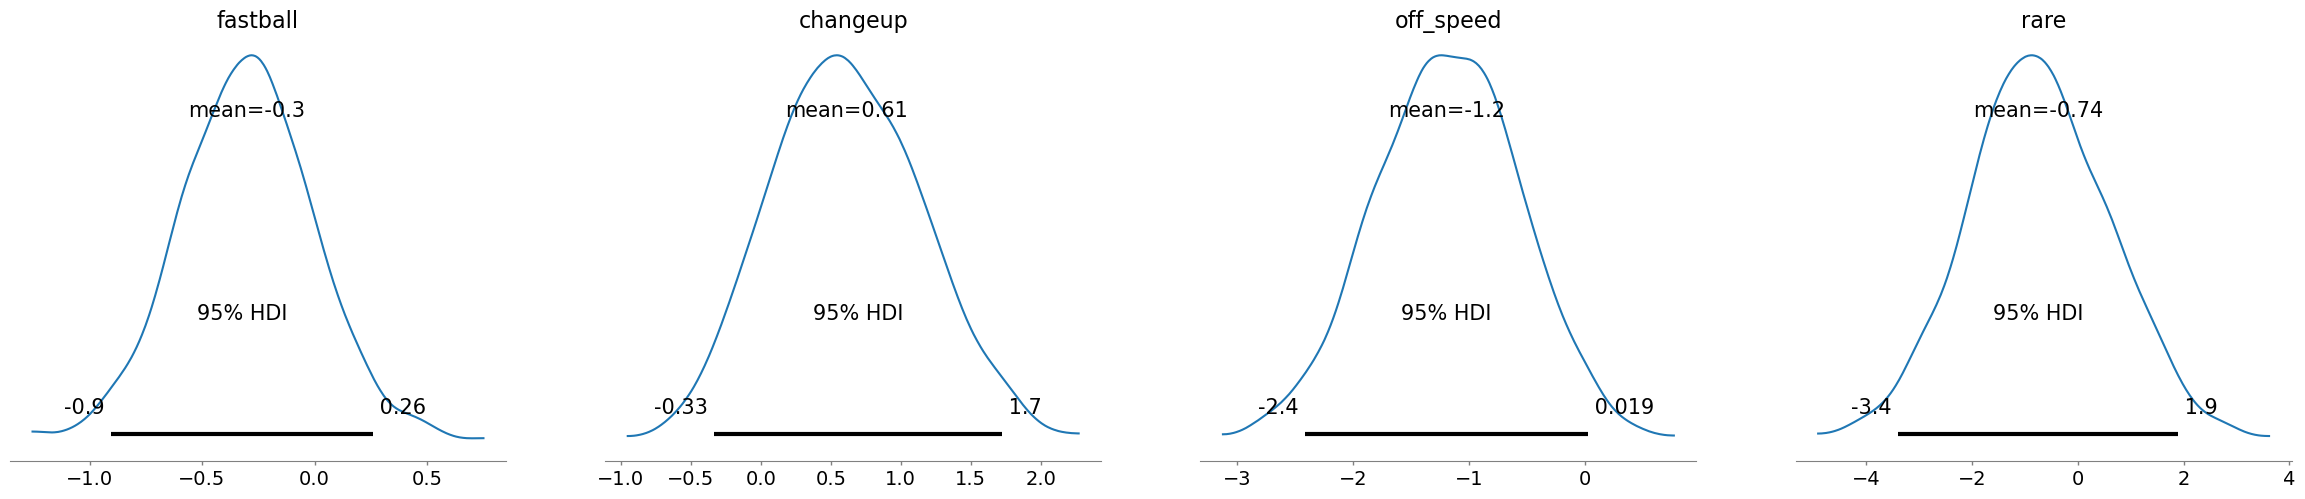

In [ ]:
with pm.Model() as pitch_type_model:
    # priors 
    intercept = pm.Normal('intercept', mu=0, sigma=10)
    fast = pm.Normal('fastball', mu=0, sigma=10)
    change = pm.Normal('changeup', mu=0, sigma=10)
    off = pm.Normal('off_speed', mu=0, sigma=10)
    rare = pm.Normal('rare', mu=0, sigma=10)

    # likelihood
    mu = intercept + fast * X[Features[0]] + change * X[Features[1]] + off * X[Features[2]] + rare * X[Features[3]]
    theta = pm.Deterministic('theta', pm.math.sigmoid(mu))
    observed = pm.Bernoulli('observed', p=theta, observed=y_true)

    #ELPD_LOO
    mean_field = pm.fit(method = 'advi', obj_optimizer = pm.adagrad_window(learning_rate=1e-2))

trace_pitch = mean_field.sample(1000)

loocv_ump3["pitch_type"] = trace_pitch

az.plot_posterior(trace_pitch, var_names=['fastball', 'changeup', 'off_speed', 'rare'], hdi_prob=0.95)

### accuracy

In [ ]:
feature_samples = {}

n_samples = len(trace_pitch.posterior['intercept'])
n_obs = len(X) 

all_preds = np.zeros((n_samples, n_obs))

for feature in ['intercept', 'fastball', 'changeup', 'off_speed', 'rare']:
    feature_samples[feature] = trace_pitch.posterior[feature].values.flatten()

for i in range(n_samples):
    mu = feature_samples['intercept'][i] + (
        (feature_samples['fastball'][i] * X[Features[0]]) +
        (feature_samples['changeup'][i] * X[Features[1]]) +
        (feature_samples['off_speed'][i] * X[Features[2]]) +
        (feature_samples['rare'][i] * X[Features[3]])
    )
    all_preds[i, :] = 1 / (1 + np.exp(-mu))

y_pred_proba = all_preds.mean(axis=0)
y_pred = (y_pred_proba > 0.5).astype(int)

accuracy = np.mean(y_pred == y_true)
model_accuracies["pitch_type"] = accuracy

print(f"Model accuracy: {model_accuracies['pitch_type']:.2f}")
print(f"Number of category 0: {np.sum(y_pred == 0)}")
print(f"Number of category 1: {np.sum(y_pred == 1)}")

Model accuracy: 0.82
Number of category 0: 180
Number of category 1: 20
